Input: Graph as manually    Output: Graph and spectral invariants


GRAPH INVARIANTS REPORT
Number of vertices:            4
Number of edges:               5
Degree sequence:               [3, 3, 2, 2]
Minimum degree:                2
Maximum degree:                3
Average degree:                2.5
Connected components:          1
Diameter:                      2
Radius:                        1
Independence number:           2
Clique number:                 3
Spectral radius:               2.561553
Algebraic connectivity:        2.0
Graph energy:                  5.123106
Number of spanning trees:      8

Adjacency eigenvalues:
[ 2.561553  0.       -1.       -1.561553]

Laplacian eigenvalues:
[0. 2. 4. 4.]

Signless Laplacian eigenvalues:
[5.236068 2.       2.       0.763932]

Adjacency eigenvectors (columns):
[[ 0.557345 -0.       -0.707107 -0.435162]
 [ 0.435162  0.707107  0.        0.557345]
 [ 0.557345 -0.        0.707107 -0.435162]
 [ 0.435162 -0.707107  0.        0.557345]]

Laplacian eigenvectors (columns):
[[ 0.5       0.       -0.866025 -

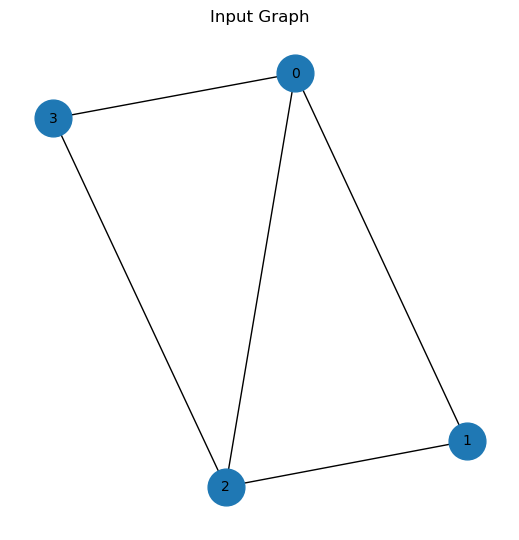

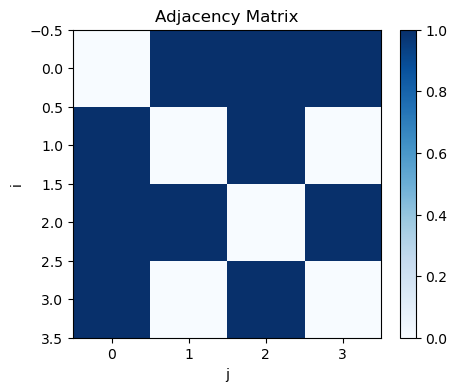

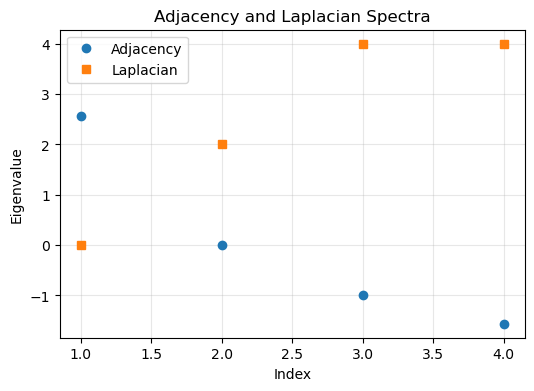

In [1]:
import itertools
import math
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# INPUT FUNCTIONS
# ============================================================

def graph_from_edge_list(edge_list, directed=False):
    """
    Build a graph from a list of edges.
    Example:
        edge_list = [(0,1), (1,2), (2,3), (3,0)]
    """
    G = nx.DiGraph() if directed else nx.Graph()
    G.add_edges_from(edge_list)
    return G


def graph_from_adjacency_matrix(A, directed=False):
    """
    Build a graph from an adjacency matrix A (numpy array or list of lists).
    """
    A = np.array(A)
    if directed:
        return nx.from_numpy_array(A, create_using=nx.DiGraph)
    return nx.from_numpy_array(A)


def generate_named_graph(name, n=None):
    """
    Generate some standard graph families.
    Supported:
        path, cycle, complete, star, empty
    """
    name = name.lower()

    if name == "path":
        return nx.path_graph(n)
    elif name == "cycle":
        return nx.cycle_graph(n)
    elif name == "complete":
        return nx.complete_graph(n)
    elif name == "star":
        return nx.star_graph(n - 1)   # star_graph(k) has k+1 vertices
    elif name == "empty":
        G = nx.Graph()
        G.add_nodes_from(range(n))
        return G
    else:
        raise ValueError(f"Unknown graph family: {name}")


# ============================================================
# BASIC MATRIX FUNCTIONS
# ============================================================

def adjacency_matrix(G):
    return nx.to_numpy_array(G, dtype=float)


def laplacian_matrix(G):
    return nx.laplacian_matrix(G).toarray().astype(float)


def signless_laplacian_matrix(G):
    A = adjacency_matrix(G)
    degrees = np.sum(A, axis=1)
    D = np.diag(degrees)
    return D + A


# ============================================================
# SPECTRAL FUNCTIONS
# ============================================================

def adjacency_spectrum(G):
    A = adjacency_matrix(G)
    eigvals, eigvecs = np.linalg.eigh(A)   # symmetric for simple undirected graphs
    order = np.argsort(eigvals)[::-1]      # descending
    return eigvals[order], eigvecs[:, order]


def laplacian_spectrum(G):
    L = laplacian_matrix(G)
    eigvals, eigvecs = np.linalg.eigh(L)
    order = np.argsort(eigvals)
    return eigvals[order], eigvecs[:, order]


def signless_laplacian_spectrum(G):
    Q = signless_laplacian_matrix(G)
    eigvals, eigvecs = np.linalg.eigh(Q)
    order = np.argsort(eigvals)[::-1]
    return eigvals[order], eigvecs[:, order]


def graph_energy(G):
    eigvals, _ = adjacency_spectrum(G)
    return float(np.sum(np.abs(eigvals)))


def spectral_radius(G):
    eigvals, _ = adjacency_spectrum(G)
    return float(np.max(np.abs(eigvals)))


def algebraic_connectivity(G):
    """
    Second-smallest Laplacian eigenvalue.
    For disconnected graphs, this is 0.
    """
    eigvals, _ = laplacian_spectrum(G)
    if len(eigvals) < 2:
        return 0.0
    return float(eigvals[1])


def number_of_spanning_trees(G):
    """
    Kirchhoff's Matrix Tree Theorem:
    delete one row and one column from L and take determinant.
    """
    if len(G) == 0:
        return 0

    if not nx.is_connected(G):
        return 0

    L = laplacian_matrix(G)
    L_minor = L[1:, 1:]
    det = round(np.linalg.det(L_minor))
    return int(det)


# ============================================================
# STRUCTURAL INVARIANTS
# ============================================================

def degree_sequence(G):
    return sorted((d for _, d in G.degree()), reverse=True)


def number_of_vertices(G):
    return G.number_of_nodes()


def number_of_edges(G):
    return G.number_of_edges()


def min_degree(G):
    if G.number_of_nodes() == 0:
        return 0
    return min(dict(G.degree()).values())


def max_degree(G):
    if G.number_of_nodes() == 0:
        return 0
    return max(dict(G.degree()).values())


def average_degree(G):
    n = G.number_of_nodes()
    if n == 0:
        return 0.0
    return 2 * G.number_of_edges() / n


def connected_components_count(G):
    return nx.number_connected_components(G)


def diameter_safe(G):
    if G.number_of_nodes() == 0:
        return 0
    if not nx.is_connected(G):
        return None
    return nx.diameter(G)


def radius_safe(G):
    if G.number_of_nodes() == 0:
        return 0
    if not nx.is_connected(G):
        return None
    return nx.radius(G)


def is_independent_set(G, subset):
    for u, v in itertools.combinations(subset, 2):
        if G.has_edge(u, v):
            return False
    return True


def independence_number_bruteforce(G):
    """
    Exact independence number by brute force.
    Suitable for small graphs only.
    """
    nodes = list(G.nodes())
    n = len(nodes)

    for r in range(n, -1, -1):
        for subset in itertools.combinations(nodes, r):
            if is_independent_set(G, subset):
                return r
    return 0


def clique_number_bruteforce(G):
    """
    Exact clique number by brute force.
    Suitable for small graphs only.
    """
    comp = nx.complement(G)
    return independence_number_bruteforce(comp)


# ============================================================
# SUMMARY REPORT
# ============================================================

def summary_report(G, compute_hard_invariants=True, hard_limit=18, digits=6):
    n = number_of_vertices(G)
    m = number_of_edges(G)

    adj_eigvals, adj_eigvecs = adjacency_spectrum(G)
    lap_eigvals, lap_eigvecs = laplacian_spectrum(G)
    signless_eigvals, signless_eigvecs = signless_laplacian_spectrum(G)

    report = {
        "n": n,
        "m": m,
        "degree_sequence": degree_sequence(G),
        "min_degree": min_degree(G),
        "max_degree": max_degree(G),
        "average_degree": average_degree(G),
        "connected_components": connected_components_count(G),
        "diameter": diameter_safe(G),
        "radius": radius_safe(G),
        "adjacency_eigenvalues": np.round(adj_eigvals, digits),
        "laplacian_eigenvalues": np.round(lap_eigvals, digits),
        "signless_laplacian_eigenvalues": np.round(signless_eigvals, digits),
        "spectral_radius": round(spectral_radius(G), digits),
        "algebraic_connectivity": round(algebraic_connectivity(G), digits),
        "graph_energy": round(graph_energy(G), digits),
        "number_of_spanning_trees": number_of_spanning_trees(G),
        "adjacency_eigenvectors": np.round(adj_eigvecs, digits),
        "laplacian_eigenvectors": np.round(lap_eigvecs, digits),
        "signless_laplacian_eigenvectors": np.round(signless_eigvecs, digits),
    }

    if compute_hard_invariants:
        if n <= hard_limit:
            report["independence_number"] = independence_number_bruteforce(G)
            report["clique_number"] = clique_number_bruteforce(G)
        else:
            report["independence_number"] = "Skipped (graph too large for exact brute force)"
            report["clique_number"] = "Skipped (graph too large for exact brute force)"

    return report


def print_summary_report(report):
    print("\n" + "=" * 60)
    print("GRAPH INVARIANTS REPORT")
    print("=" * 60)

    print(f"Number of vertices:            {report['n']}")
    print(f"Number of edges:               {report['m']}")
    print(f"Degree sequence:               {report['degree_sequence']}")
    print(f"Minimum degree:                {report['min_degree']}")
    print(f"Maximum degree:                {report['max_degree']}")
    print(f"Average degree:                {report['average_degree']}")
    print(f"Connected components:          {report['connected_components']}")
    print(f"Diameter:                      {report['diameter']}")
    print(f"Radius:                        {report['radius']}")
    print(f"Independence number:           {report.get('independence_number', 'N/A')}")
    print(f"Clique number:                 {report.get('clique_number', 'N/A')}")
    print(f"Spectral radius:               {report['spectral_radius']}")
    print(f"Algebraic connectivity:        {report['algebraic_connectivity']}")
    print(f"Graph energy:                  {report['graph_energy']}")
    print(f"Number of spanning trees:      {report['number_of_spanning_trees']}")

    print("\nAdjacency eigenvalues:")
    print(report["adjacency_eigenvalues"])

    print("\nLaplacian eigenvalues:")
    print(report["laplacian_eigenvalues"])

    print("\nSignless Laplacian eigenvalues:")
    print(report["signless_laplacian_eigenvalues"])

    print("\nAdjacency eigenvectors (columns):")
    print(report["adjacency_eigenvectors"])

    print("\nLaplacian eigenvectors (columns):")
    print(report["laplacian_eigenvectors"])

    print("\nSignless Laplacian eigenvectors (columns):")
    print(report["signless_laplacian_eigenvectors"])

    print("=" * 60 + "\n")


# ============================================================
# VISUALIZATION
# ============================================================

def draw_graph(G, title="Graph"):
    plt.figure(figsize=(5, 5))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(
        G,
        pos,
        with_labels=True,
        node_size=700,
        font_size=10,
    )
    plt.title(title)
    plt.show()


def plot_adjacency_heatmap(G, title="Adjacency Matrix"):
    A = adjacency_matrix(G)
    plt.figure(figsize=(5, 4))
    plt.imshow(A, cmap="Blues", interpolation="nearest")
    plt.colorbar()
    plt.title(title)
    plt.xlabel("j")
    plt.ylabel("i")
    plt.show()


def plot_spectra(G):
    adj_eigvals, _ = adjacency_spectrum(G)
    lap_eigvals, _ = laplacian_spectrum(G)

    plt.figure(figsize=(6, 4))
    plt.plot(range(1, len(adj_eigvals) + 1), adj_eigvals, 'o', label="Adjacency")
    plt.plot(range(1, len(lap_eigvals) + 1), lap_eigvals, 's', label="Laplacian")
    plt.xlabel("Index")
    plt.ylabel("Eigenvalue")
    plt.title("Adjacency and Laplacian Spectra")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


# ============================================================
# EXAMPLE USAGE
# ============================================================

if __name__ == "__main__":
    # Example 1: manual edge list
    edge_list = [(0, 1), (1, 2), (2, 3), (3, 0), (0, 2)]
    G = graph_from_edge_list(edge_list)

    # Example 2: named graph
    # G = generate_named_graph("cycle", n=6)

    # Example 3: adjacency matrix
    # A = [
    #     [0, 1, 1, 0],
    #     [1, 0, 1, 1],
    #     [1, 1, 0, 0],
    #     [0, 1, 0, 0]
    # ]
    # G = graph_from_adjacency_matrix(A)

    report = summary_report(G, compute_hard_invariants=True, hard_limit=18)
    print_summary_report(report)

    draw_graph(G, title="Input Graph")
    plot_adjacency_heatmap(G)
    plot_spectra(G)